# Advanced Analysis and Model Refinement: Hybrid Recommendation System

## Introduction

This notebook continues the recommendation-system analysis by focusing on model refinement. The goal is to test different signal combinations, blend weights, and ranking adjustments and evaluate their effect on recommendation quality.

The baseline model combines SVD collaborative filtering with TF-IDF content similarity. In this stage, I revisit the assumptions behind the model, examine performance across different levels of customer history, and consider tradeoffs between recommendation quality, catalog coverage, and popularity.

Model choices are made using the validation set, while the test set is reserved for final evaluation after the refinement decisions are made.

In [1]:
import sys, os
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, spearmanr

from pipeline import make_data, run_pipeline, per_user_metrics, topk
from evaluation import bootstrap_ci, sampled_roc, topk_confusion, metrics_at_k
from refinement import (train_matrix, svd_scores, item_text, content_scores, popularity_vector,
                        adaptive_weight, blend, popularity_rerank, fast_topk, time_it)

FIG_DIR = "../reports/figures/refinement_copy"
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name):
    plt.savefig(FIG_DIR + "/" + name + ".png", dpi=150, bbox_inches="tight")

events, products = make_data(seed=42)
state = run_pipeline(events, products, k=12, n_full=8)   # same settings as implementation stage
val = state["validation"]
test = state["test"]
n_hist = state["n_hist"]
print(len(state["user_ids"]), "users,", len(state["prod_ids"]), "products")
print("train/val/test rows:", len(state["train"]), len(val), len(test))

3824 users, 1983 products
train/val/test rows: 46424 6606 13207


In [2]:
def evaluate(scores, df, k=10):
    # per-user metrics from the pipeline, plus F1
    d = per_user_metrics(scores, state, df, k=k)
    denom = (d.precision + d.recall).replace(0, 1)
    d["f1"] = 2 * d.precision * d.recall / denom
    return d

def ndcg(scores, df):
    return per_user_metrics(scores, state, df).ndcg.mean()

def before_after(ax, labels, values, title, ylabel="NDCG@10"):
    bars = ax.bar(labels, values, color=["gray", "#2b6cb0"])
    ax.bar_label(bars, fmt="%.4f", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(values) * 1.2)

# fixed svds start vector so the 4th decimal does not change between runs
M = train_matrix(state, "rating")
svd12 = svd_scores(M, k=12)
text_cp = item_text(products, state["prod_ids"], ["category", "price_bucket"])
content_cp, n_texts = content_scores(state, text_cp)
pop = popularity_vector(state)

S = {}
S["Fixed 50/50 hybrid"] = blend(svd12, content_cp, 0.5)
S["SVD only"] = svd12
S["Hybrid (adaptive)"] = blend(svd12, content_cp, adaptive_weight(n_hist, 3, 8, 0.0))
S["Most popular"] = np.tile(pop, (len(state["user_ids"]), 1))
S["TF-IDF only"] = content_cp
S["Random"] = np.random.default_rng(0).random(svd12.shape)

## 1. Detailed Model Evaluation

The fixed 50/50 blend was the model I had recommended before, so it is the starting point here. I added F1@10 because precision and recall can move in different directions as the list gets longer. NDCG@10 is still the main metric because it gives more credit when relevant items appear near the top of the list.

In [3]:
rows = []
per_user = {}
for name in S:
    d = evaluate(S[name], val)   # validation only here, test is saved for the end
    per_user[name] = d
    mean, lo, hi = bootstrap_ci(d.ndcg)
    rows.append([name, d.precision.mean(), d.recall.mean(), d.f1.mean(), mean, f"[{lo:.4f}, {hi:.4f}]"])

base_table = pd.DataFrame(rows, columns=["model", "precision@10", "recall@10", "F1@10", "NDCG@10", "NDCG 95% CI"])
base_table = base_table.set_index("model")

# numbers used in the benchmark discussion below
p_pop = wilcoxon(per_user["Fixed 50/50 hybrid"].ndcg, per_user["Most popular"].ndcg).pvalue
lift = base_table.loc["Fixed 50/50 hybrid", "NDCG@10"] / base_table.loc["Most popular", "NDCG@10"] - 1
coverage_start = len(np.unique(topk(S["Fixed 50/50 hybrid"], state["seen_mask"]))) / len(state["prod_ids"])
print("lift over popularity: +%.0f%% | Wilcoxon p = %.1e | starting coverage: %.0f%%" % (lift * 100, p_pop, coverage_start * 100))
base_table.round(4)

lift over popularity: +65% | Wilcoxon p = 1.1e-12 | starting coverage: 54%


,precision@10,recall@10,F1@10,NDCG@10,NDCG 95% CI
model,,,,,
Fixed 50/50 hybrid,0.0254,0.1391,0.0386,0.0997,"[0.0892, 0.1111]"
SVD only,0.0264,0.1477,0.0407,0.0974,"[0.0872, 0.1082]"
Hybrid (adaptive),0.0212,0.1048,0.0315,0.0701,"[0.0615, 0.0786]"
Most popular,0.0170,0.0976,0.0265,0.0603,"[0.0523, 0.0686]"
TF-IDF only,0.0073,0.0335,0.0098,0.0194,"[0.0149, 0.0239]"
Random,0.0007,0.0046,0.0011,0.0027,"[0.0011, 0.0047]"


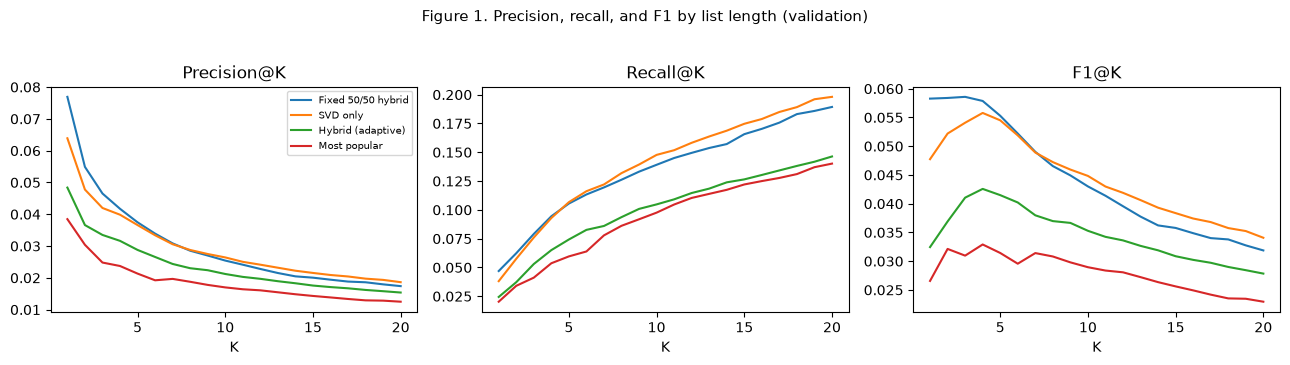

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for model_name in ["Fixed 50/50 hybrid", "SVD only", "Hybrid (adaptive)", "Most popular"]:
    curve = metrics_at_k(S[model_name], state, val, ks=range(1, 21))
    f1 = 2 * curve.precision * curve.recall / (curve.precision + curve.recall)
    axes[0].plot(curve.K, curve.precision, label=model_name)
    axes[1].plot(curve.K, curve.recall, label=model_name)
    axes[2].plot(curve.K, f1, label=model_name)

axes[0].set_title("Precision@K")
axes[1].set_title("Recall@K")
axes[2].set_title("F1@K")
for axis in axes:
    axis.set_xlabel("K")
axes[0].legend(fontsize=7)
fig.suptitle("Figure 1. Precision, recall, and F1 by list length (validation)", y=1.03, fontsize=11)
plt.tight_layout()
savefig("refinement_fig1_prf1_at_k_baseline")
plt.show()

F1 is strongest at shorter recommendation lists, which fits the goal of ranking a small number of relevant items near the top.

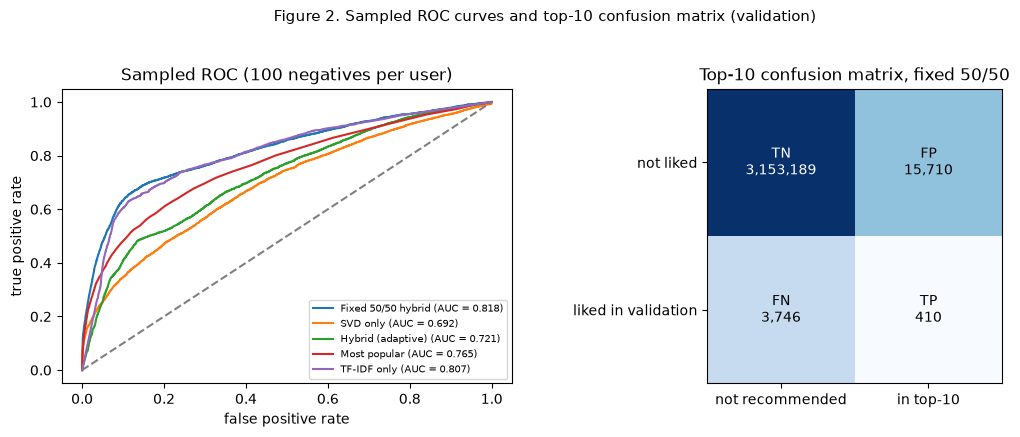

accuracy: 0.9939 | accuracy if we recommend nothing: 0.9987


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for model_name in ["Fixed 50/50 hybrid", "SVD only", "Hybrid (adaptive)", "Most popular", "TF-IDF only"]:
    fpr, tpr, auc = sampled_roc(S[model_name], state, val)
    axes[0].plot(fpr, tpr, label=model_name + " (AUC = %.3f)" % auc)
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].set_title("Sampled ROC (100 negatives per user)")
axes[0].legend(fontsize=7, loc="lower right")

cm = topk_confusion(S["Fixed 50/50 hybrid"], state, val, k=10)
axes[1].imshow(np.log10(cm), cmap="Blues")
names = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        color = "white" if np.log10(cm[i, j]) > 5 else "black"
        axes[1].text(j, i, names[i][j] + "\n" + format(cm[i, j], ","), ha="center", va="center", color=color)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["not recommended", "in top-10"])
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["not liked", "liked in validation"])
axes[1].set_title("Top-10 confusion matrix, fixed 50/50")
fig.suptitle("Figure 2. Sampled ROC curves and top-10 confusion matrix (validation)", y=1.03, fontsize=11)
plt.tight_layout()
savefig("refinement_fig2_roc_confusion_baseline")
plt.show()

tn, fp, fn, tp = cm.ravel()
print("accuracy:", round((tp + tn) / cm.sum(), 4), "| accuracy if we recommend nothing:", round((tn + fp) / cm.sum(), 4))

The hybrid blends appear to rank broad categories well (validation AUC 0.818 for the fixed blend), while SVD is sharper near the top of the list (AUC 0.692). Because these ROC curves use sampled negatives, I treat AUC as supporting evidence rather than the main result (Krichene & Rendle, 2020). The confusion matrix also shows why accuracy is not a useful standalone metric here: most user-item pairs are negative, so recommending nothing would score 0.999 accuracy, higher than the blend's 0.994.

The fixed blend performs better than popularity on validation NDCG and covers more of the catalog than SVD. Its weaknesses are an untuned blend weight, a strong lean toward popular products (73% of top-10 slots), only 46 distinct product texts, and weak results for customers with 1-4 interactions in the adaptive version.

### Benchmark context

On validation, the fixed blend gives a 65% NDCG@10 lift over popularity (paired Wilcoxon p = 1.1e-12). The table shows where the starting model meets or falls short on each point:

| Evaluation perspective | Evidence in this project | Meets / falls short |
| --- | --- | --- |
| Personalization against a simple baseline (Cremonesi et al., 2010) | The fixed blend has higher validation NDCG@10 than popularity | **Meets.** The blend ranks liked items better than this baseline on this split |
| Beyond-accuracy outcomes (Kaminskas & Bridge, 2016) | Starting coverage is 54%; head-item exposure and history tiers are also examined | **Meets.** Accuracy is considered alongside catalog reach and differences across users |
| Performance by customer history | The initial adaptive blend performs poorly for customers with 1-4 interactions | **Falls short.** This motivates testing other blend choices |
| Model selection and final evaluation (Ferrari Dacrema et al., 2019) | k and n_full tuned on validation; test used only after selection | **Partly.** The blend weight had not been tuned yet |
| Evidence for deployment (Jannach & Jugovac, 2019) | Synthetic interaction data and offline evaluation only | **Falls short.** Real interaction data and online testing are future work |

These are project-level checks from a synthetic offline evaluation, not universal industry thresholds.

## 2. Revisiting Assumptions

1. *Low-history customers need content signals.* This justified the adaptive weight, but the history results above contradict it.
2. *Price bucket describes what customers want.* Never tested.
3. *50/50 is a reasonable blend.* Never validated.
4. *Raw star ratings are the right SVD input.* With 72% of ratings at 4-5 stars, whether an interaction happened may matter more.
5. The catalog's `avg_rating` uses all events, including test, so any rating feature below is computed from training data only.

## 3. Iterative Refinement

Each change is tested on validation by itself. If it helps, it becomes the new baseline; otherwise, it is recorded and discarded.

### R1: Removing the zero floor in the adaptive weight

Customers with three or fewer interactions got a collaborative weight of zero. I added a floor so everyone keeps some SVD signal, keeping the weighted-hybrid idea (Burke, 2002) without the hard cutoff.

n_full       8       15      30
w_floor                        
0.0      0.0701  0.0697  0.0673
0.3      0.0907  0.0919  0.0939
0.5      0.0975  0.0979  0.1007
0.7      0.0977  0.0998  0.1029
0.9      0.0992  0.1007  0.1031
best: 0.9 30


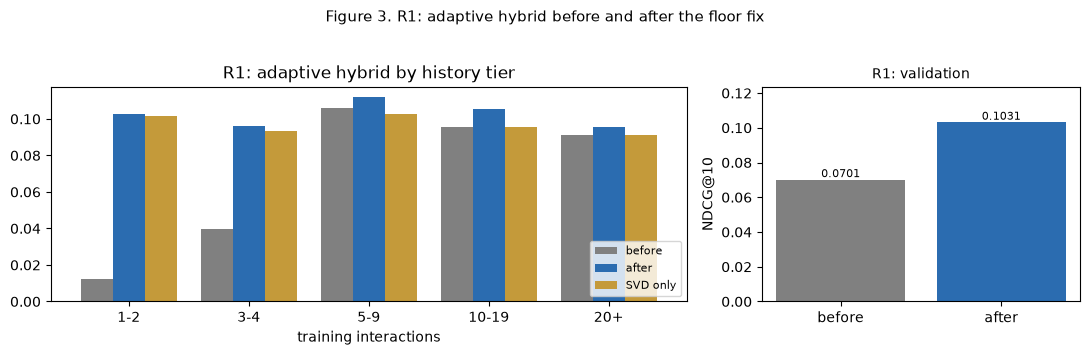

In [6]:
# grid search floor x ramp length on validation
r1 = []
for w_floor in [0.0, 0.3, 0.5, 0.7, 0.9]:
    for n_full in [8, 15, 30]:
        scores = blend(svd12, content_cp, adaptive_weight(n_hist, 3, n_full, w_floor))
        r1.append([w_floor, n_full, ndcg(scores, val)])
r1 = pd.DataFrame(r1, columns=["w_floor", "n_full", "val_ndcg"])
print(r1.pivot(index="w_floor", columns="n_full", values="val_ndcg").round(4))

best = r1.sort_values("val_ndcg").iloc[-1]
print("best:", best.w_floor, int(best.n_full))
adaptive_fixed = blend(svd12, content_cp, adaptive_weight(n_hist, 3, int(best.n_full), best.w_floor))

tiers_bins = [0, 2, 4, 9, 19, np.inf]
tiers_labels = ["1-2", "3-4", "5-9", "10-19", "20+"]
def by_tier(scores, data):
    metrics = evaluate(scores, data)
    return metrics.groupby(pd.cut(metrics.n_hist, tiers_bins, labels=tiers_labels), observed=True).ndcg.mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [2, 1]})
tier_results = pd.DataFrame({
    "before": by_tier(S["Hybrid (adaptive)"], val),
    "after": by_tier(adaptive_fixed, val),
    "SVD only": by_tier(svd12, val),
})
tier_results.plot(kind="bar", ax=axes[0], width=0.8, color=["gray", "#2b6cb0", "#c49a3a"])
axes[0].set_title("R1: adaptive hybrid by history tier")
axes[0].set_xlabel("training interactions")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].tick_params(axis="x", rotation=0)
before_after(axes[1], ["before", "after"], [ndcg(S["Hybrid (adaptive)"], val), ndcg(adaptive_fixed, val)], "R1: validation")
fig.suptitle("Figure 3. R1: adaptive hybrid before and after the floor fix", y=1.03, fontsize=11)
plt.tight_layout()
savefig("refinement_fig3_r1_floor_fix")
plt.show()

The lowest-history tier improves in validation (0.013 to 0.102), and the overall validation score rises from 0.0699 to 0.1031. The selected floor is high (0.9) and the ramp is slow (n_full = 30), so the weight changes only a little across history levels. I therefore moved on to tuning a fixed blend weight.

### R2: Tuning the blend weight

The blend is alpha × SVD + (1 − alpha) × TF-IDF, and alpha was 0.5 before.

chosen alpha: 0.8


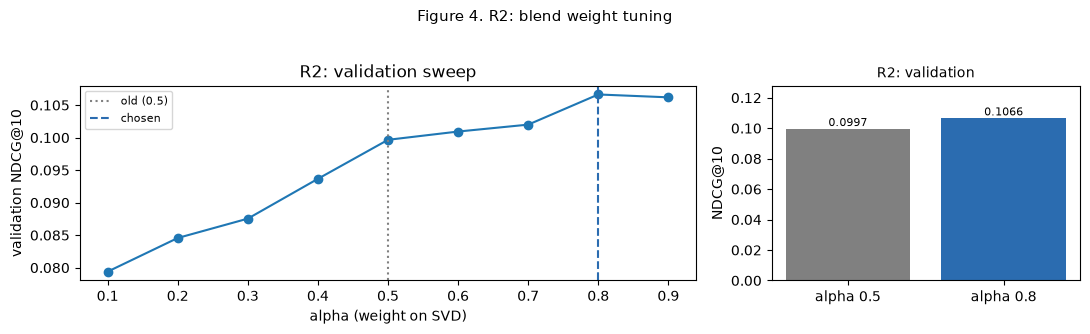

In [7]:
alphas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
val_curve = [ndcg(blend(svd12, content_cp, alpha), val) for alpha in alphas]
alpha2 = alphas[int(np.argmax(val_curve))]
model_r2 = blend(svd12, content_cp, alpha2)
print("chosen alpha:", alpha2)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(alphas, val_curve, "o-")
axes[0].axvline(0.5, ls=":", color="gray", label="old (0.5)")
axes[0].axvline(alpha2, ls="--", color="#2b6cb0", label="chosen")
axes[0].set_xlabel("alpha (weight on SVD)")
axes[0].set_ylabel("validation NDCG@10")
axes[0].legend(fontsize=8)
axes[0].set_title("R2: validation sweep")
before_after(axes[1], ["alpha 0.5", "alpha %.1f" % alpha2],
             [ndcg(S["Fixed 50/50 hybrid"], val), ndcg(model_r2, val)], "R2: validation")
fig.suptitle("Figure 4. R2: blend weight tuning", y=1.03, fontsize=11)
plt.tight_layout()
savefig("refinement_fig4_r2_alpha")
plt.show()

Validation favors more SVD weight (alpha = 0.8), since tied content scores add noise near the top of the list. Validation NDCG rises from 0.0997 to 0.1066.

### R3: Content feature engineering

Rather than just turning content down, I tried improving it and re-tuned alpha for each option:

- **+ rating tier:** a high, middle, or low token from the product's *training* average rating
- **rating-weighted profile:** all rated items count, weighted by (rating − 3)
- **category only:** drop price bucket (assumption 2)

                            distinct texts  best alpha  val NDCG@10
variant                                                            
category + price (current)              46         0.8       0.1066
+ rating tier                           98         0.8       0.1065
rating-weighted profile                 46         0.8       0.1066
category only                           10         0.1       0.1132


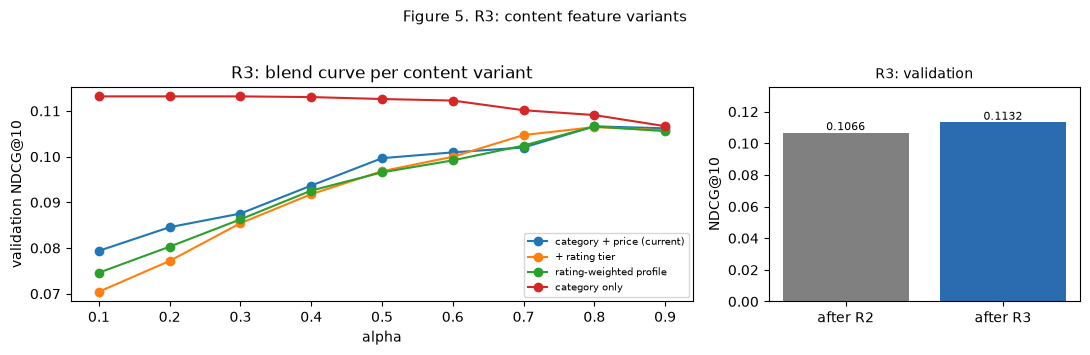

In [8]:
avg_train = state["train_agg"].groupby("product_id").rating.mean().to_dict()
variants = {
    "category + price (current)": (["category", "price_bucket"], "liked_mean"),
    "+ rating tier": (["category", "price_bucket", "rating_tier"], "liked_mean"),
    "rating-weighted profile": (["category", "price_bucket"], "rating_weighted"),
    "category only": (["category"], "liked_mean"),
}
r3 = []
curves = {}
contents = {}
for name, (fields, profile) in variants.items():
    text_features = item_text(products, state["prod_ids"], fields, avg_train)
    content_scores_for_variant, n_distinct = content_scores(state, text_features, profile)
    contents[name] = content_scores_for_variant
    curves[name] = [ndcg(blend(svd12, content_scores_for_variant, alpha), val) for alpha in alphas]
    best_index = int(np.argmax(curves[name]))
    r3.append([name, n_distinct, alphas[best_index], curves[name][best_index]])
r3 = pd.DataFrame(r3, columns=["variant", "distinct texts", "best alpha", "val NDCG@10"]).set_index("variant")
print(r3.round(4))

best_variant = r3["val NDCG@10"].idxmax()
alpha3 = r3.loc[best_variant, "best alpha"]
content_best = contents[best_variant]
model_r3 = blend(svd12, content_best, alpha3)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [2, 1]})
for name, curve in curves.items():
    axes[0].plot(alphas, curve, marker="o", label=name)
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("validation NDCG@10")
axes[0].legend(fontsize=7)
axes[0].set_title("R3: blend curve per content variant")
before_after(axes[1], ["after R2", "after R3"],
             [ndcg(model_r2, val), ndcg(model_r3, val)], "R3: validation")
fig.suptitle("Figure 5. R3: content feature variants", y=1.03, fontsize=11)
plt.tight_layout()
savefig("refinement_fig5_r3_content_features")
plt.show()

The biggest gain came from *removing* a feature. Rating tier and the weighted profile barely changed the blend, but dropping price lifted validation NDCG from 0.1066 to 0.1132 and moved the best alpha to 0.1. This was unexpected, but with only ten distinct texts the content score works like a category filter, and SVD orders items within each category.

### R4: SVD input signal and number of factors

I tested assumption 4 with binary and user-mean-centered inputs, sweeping k for each (Koren et al., 2009, discuss both input types).

    rating  binary  centered
5   0.1131  0.1093    0.0407
8   0.1110  0.1098    0.0409
10  0.1136  0.1112    0.0510
12  0.1132  0.1099    0.0578
15  0.1070  0.1094    0.0594
20  0.0986  0.0994    0.0618
30  0.0918  0.0862    0.0609


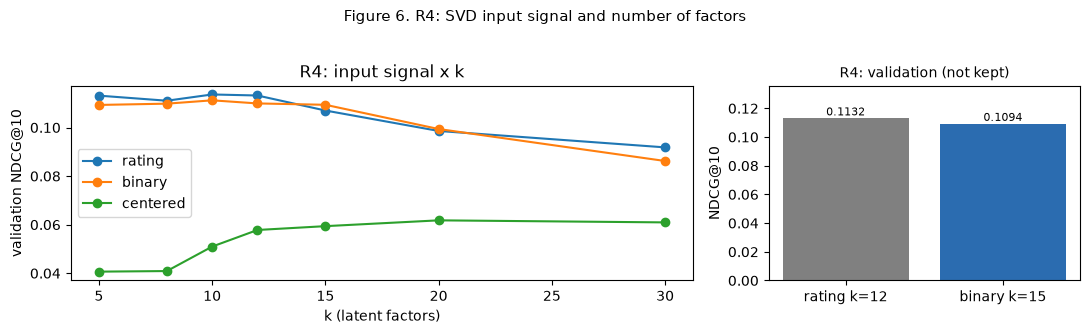

In [9]:
ks = [5, 8, 10, 12, 15, 20, 30]
r4 = {}
for signal in ["rating", "binary", "centered"]:
    rating_matrix = train_matrix(state, signal)
    r4[signal] = [ndcg(blend(svd_scores(rating_matrix, k), content_best, alpha3), val) for k in ks]
r4 = pd.DataFrame(r4, index=ks)
print(r4.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), gridspec_kw={"width_ratios": [2, 1]})
r4.plot(marker="o", ax=axes[0])
axes[0].set_xlabel("k (latent factors)")
axes[0].set_ylabel("validation NDCG@10")
axes[0].set_title("R4: input signal x k")
binary_scores = blend(svd_scores(train_matrix(state, "binary"), 15), content_best, alpha3)
before_after(axes[1], ["rating k=12", "binary k=15"],
             [ndcg(model_r3, val), ndcg(binary_scores, val)], "R4: validation (not kept)")
fig.suptitle("Figure 6. R4: SVD input signal and number of factors", y=1.03, fontsize=11)
plt.tight_layout()
savefig("refinement_fig6_r4_svd_signal")
plt.show()

Raw ratings remain the best input in this comparison (0.1132, vs. 0.1112 for binary and 0.0618 for centered). The validation scores for k = 10 and k = 12 are close (0.1136 vs. 0.1132), so I kept k = 12 rather than changing it for a small difference. No R4 change was kept.

### R5: Popularity-aware re-ranking

R2 and R3 raised accuracy but reduced coverage. A common response is to apply a small popularity penalty before ranking (Abdollahpouri et al., 2017). I chose the largest lambda for which validation NDCG stayed within 1% of the value without re-ranking.

 lambda  val_ndcg  coverage  head_share
 0.0000    0.1132    0.3626      0.8978
 0.0025    0.1123    0.4584      0.8622
 0.0050    0.1095    0.4912      0.7892
 0.0075    0.1055    0.4816      0.7204
 0.0100    0.1008    0.4695      0.6562
 0.0150    0.0874    0.4281      0.5421
 0.0200    0.0752    0.3757      0.4271
 0.0300    0.0636    0.2945      0.2766
chosen lambda: 0.0025


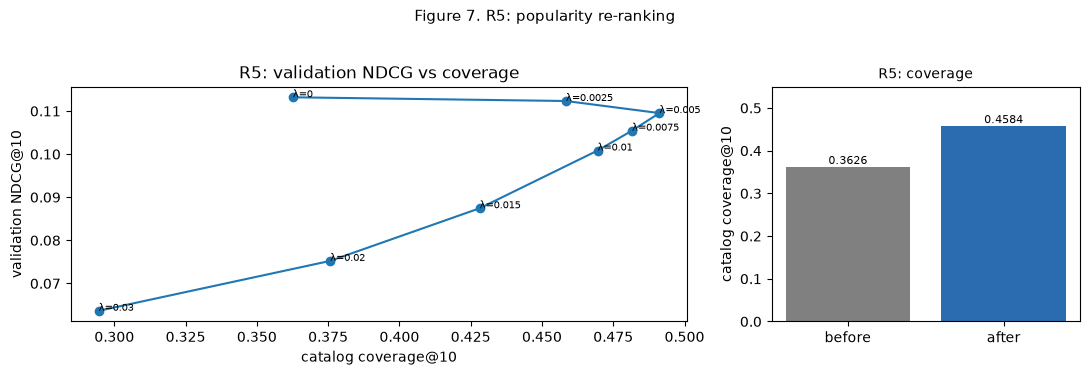

In [10]:
head_items = np.argsort(-pop)[: int(0.10 * len(pop))]
def coverage_and_head(scores):
    recommendations = topk(scores, state["seen_mask"])
    coverage = len(np.unique(recommendations)) / len(pop)
    head_share = np.isin(recommendations, head_items).mean()
    return coverage, head_share

# sweep the penalty, keep track of coverage too
r5 = []
for penalty in [0, 0.0025, 0.005, 0.0075, 0.01, 0.015, 0.02, 0.03]:
    scores = popularity_rerank(model_r3, pop, penalty)
    coverage, head_share = coverage_and_head(scores)
    r5.append([penalty, ndcg(scores, val), coverage, head_share])
r5 = pd.DataFrame(r5, columns=["lambda", "val_ndcg", "coverage", "head_share"])
print(r5.round(4).to_string(index=False))

eligible = r5[r5.val_ndcg >= 0.99 * r5.val_ndcg[0]]
lam5 = eligible["lambda"].max()
print("chosen lambda:", lam5)
model_final = popularity_rerank(model_r3, pop, lam5)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(r5.coverage, r5.val_ndcg, "o-")
for i in range(len(r5)):
    axes[0].annotate("λ=%g" % r5["lambda"][i], (r5.coverage[i], r5.val_ndcg[i]), fontsize=7)
axes[0].set_xlabel("catalog coverage@10")
axes[0].set_ylabel("validation NDCG@10")
axes[0].set_title("R5: validation NDCG vs coverage")
coverage_before = coverage_and_head(model_r3)[0]
coverage_after = coverage_and_head(model_final)[0]
before_after(axes[1], ["before", "after"], [coverage_before, coverage_after],
             "R5: coverage", ylabel="catalog coverage@10")
fig.suptitle("Figure 7. R5: popularity re-ranking", y=1.03, fontsize=11)
plt.tight_layout()
savefig("refinement_fig7_r5_rerank")
plt.show()

The selected penalty (lambda = 0.0025) improves catalog coverage from 36% to 46% while keeping validation NDCG within the 1% limit (0.1132 to 0.1123). Coverage is still lower than the starting blend's 54%.

### R6: Efficiency

The original ranking function fully sorted about 2,000 items per customer to return ten. I compared it with an `argpartition` version, and also checked how much memory a float32 copy of the score matrix would use.

seconds for all users - old: 0.368  new: 0.087
identical recommendation lists: 1.0


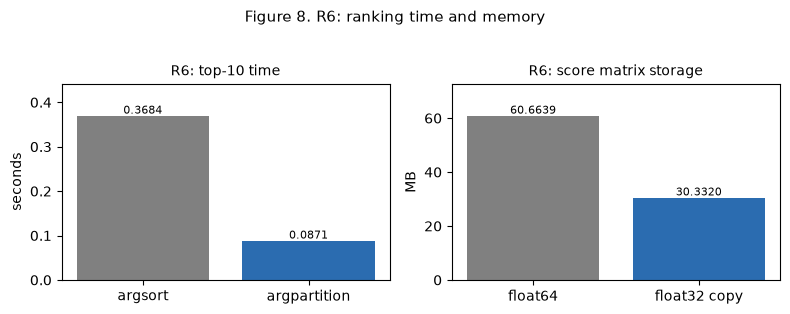

In [11]:
# timings are noisy, so median of 9 runs
t_old = time_it(lambda: topk(model_final, state["seen_mask"]), repeats=9)
t_new = time_it(lambda: fast_topk(model_final, state["seen_mask"]), repeats=9)
old_recommendations = topk(model_final, state["seen_mask"])
new_recommendations = fast_topk(model_final, state["seen_mask"])
same = (old_recommendations == new_recommendations).mean()
print("seconds for all users - old: %.3f  new: %.3f" % (t_old, t_new))
print("identical recommendation lists:", same)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
before_after(axes[0], ["argsort", "argpartition"], [t_old, t_new], "R6: top-10 time", ylabel="seconds")
memory_mb = [model_final.nbytes / 1e6, model_final.astype(np.float32).nbytes / 1e6]
before_after(axes[1], ["float64", "float32 copy"], memory_mb,
             "R6: score matrix storage", ylabel="MB")
fig.suptitle("Figure 8. R6: ranking time and memory", y=1.03, fontsize=11)
plt.tight_layout()
savefig("refinement_fig8_r6_efficiency")
plt.show()

The `argpartition` version returned identical top-10 lists and was about four times faster in the saved run (0.087 s compared with 0.368 s for all users; exact times depend on the machine). Storing the score matrix as float32 would use about half the memory (30 MB vs. 61 MB), but this notebook only measures that comparison; it does not change the model's storage type.

### Summary of refinements

                   precision  recall      F1  test NDCG  val NDCG  coverage  \
stage                                                                         
Start: 50/50          0.0313  0.1319  0.0428     0.0990    0.0997    0.5421   
R2: alpha             0.0357  0.1526  0.0496     0.1073    0.1066    0.3747   
R3: category only     0.0379  0.1663  0.0531     0.1208    0.1132    0.3626   
R5: re-rank           0.0373  0.1634  0.0522     0.1193    0.1123    0.4584   

                   head share  
stage                          
Start: 50/50           0.7276  
R2: alpha              0.8672  
R3: category only      0.8978  
R5: re-rank            0.8622  

final vs start  p = 2.4e-09
final vs SVD    p = 2.3e-28


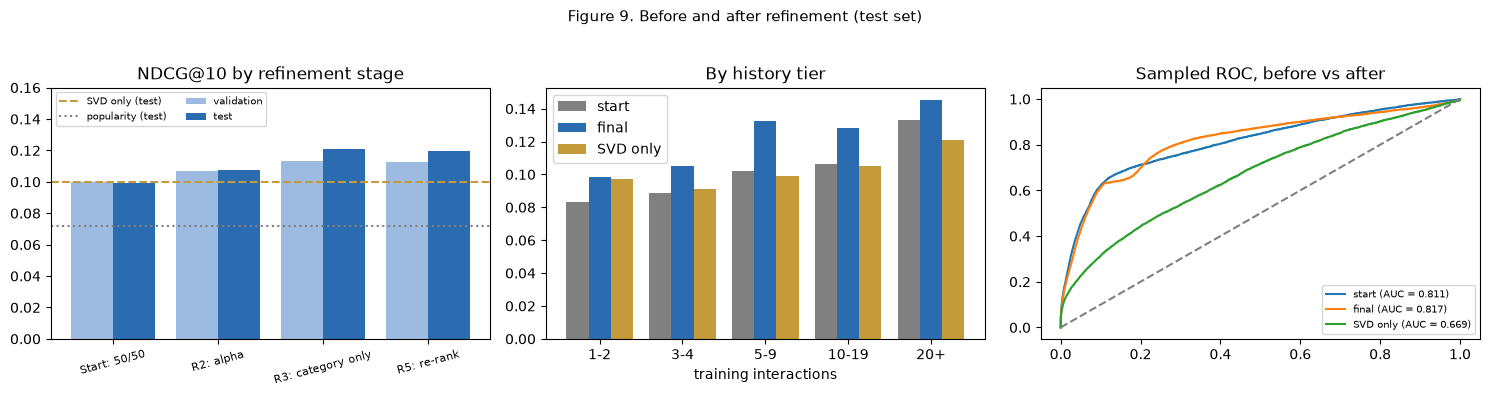

In [12]:
stages = [("Start: 50/50", S["Fixed 50/50 hybrid"]), ("R2: alpha", model_r2),
          ("R3: category only", model_r3), ("R5: re-rank", model_final)]
summ = []
for name, scores in stages:
    test_metrics = evaluate(scores, test)
    coverage, head_share = coverage_and_head(scores)
    summ.append([name, test_metrics.precision.mean(), test_metrics.recall.mean(),
                 test_metrics.f1.mean(), test_metrics.ndcg.mean(), ndcg(scores, val),
                 coverage, head_share])
summ = pd.DataFrame(summ, columns=["stage", "precision", "recall", "F1", "test NDCG",
                                  "val NDCG", "coverage", "head share"])
print(summ.set_index("stage").round(4))

# Compare final and baseline models on the same held-out test set.
test_baselines = {
    "Fixed 50/50 hybrid": evaluate(S["Fixed 50/50 hybrid"], test),
    "SVD only": evaluate(S["SVD only"], test),
    "Most popular": evaluate(S["Most popular"], test),
}
final_test = evaluate(model_final, test)
print("\nfinal vs start  p =", "%.1e" % wilcoxon(final_test.ndcg, test_baselines["Fixed 50/50 hybrid"].ndcg).pvalue)
print("final vs SVD    p =", "%.1e" % wilcoxon(final_test.ndcg, test_baselines["SVD only"].ndcg).pvalue)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
stage_positions = np.arange(len(summ))
axes[0].bar(stage_positions - 0.2, summ["val NDCG"], 0.4, label="validation", color="#9dbbe0")
axes[0].bar(stage_positions + 0.2, summ["test NDCG"], 0.4, label="test", color="#2b6cb0")
axes[0].axhline(test_baselines["SVD only"].ndcg.mean(), ls="--", color="#c49a3a", label="SVD only (test)")
axes[0].axhline(test_baselines["Most popular"].ndcg.mean(), ls=":", color="gray", label="popularity (test)")
axes[0].set_xticks(stage_positions)
axes[0].set_xticklabels(summ.stage, rotation=15, fontsize=8)
axes[0].set_ylim(0, 0.16)
axes[0].legend(fontsize=7, ncol=2, loc="upper left")
axes[0].set_title("NDCG@10 by refinement stage")

tier_results = pd.DataFrame({
    "start": by_tier(S["Fixed 50/50 hybrid"], test),
    "final": by_tier(model_final, test),
    "SVD only": by_tier(svd12, test),
})
tier_results.plot(kind="bar", ax=axes[1], width=0.8, color=["gray", "#2b6cb0", "#c49a3a"])
axes[1].set_title("By history tier")
axes[1].set_xlabel("training interactions")
axes[1].tick_params(axis="x", rotation=0)

for model_name, scores in [("start", S["Fixed 50/50 hybrid"]), ("final", model_final), ("SVD only", svd12)]:
    fpr, tpr, auc = sampled_roc(scores, state, test)
    axes[2].plot(fpr, tpr, label=model_name + " (AUC = %.3f)" % auc)
axes[2].plot([0, 1], [0, 1], "--", color="gray")
axes[2].legend(fontsize=7, loc="lower right")
axes[2].set_title("Sampled ROC, before vs after")
fig.suptitle("Figure 9. Before and after refinement (test set)", y=1.03, fontsize=11)
plt.tight_layout()
savefig("refinement_fig9_refinement_summary")
plt.show()

In [13]:
# check whether the result holds on other generated datasets
# only alpha is retuned per seed, feature choice and penalty stay fixed
seed_rows = []
for seed in [42, 7, 123, 2024, 99]:
    events_seed, products_seed = make_data(seed=seed)
    seed_state = run_pipeline(events_seed, products_seed, k=12, n_full=8)
    seed_svd = svd_scores(train_matrix(seed_state, "rating"), 12)
    original_content, _ = content_scores(
        seed_state, item_text(products_seed, seed_state["prod_ids"], ["category", "price_bucket"])
    )
    category_content, _ = content_scores(
        seed_state, item_text(products_seed, seed_state["prod_ids"], ["category"])
    )
    validation_scores = [
        per_user_metrics(blend(seed_svd, category_content, alpha), seed_state,
                         seed_state["validation"]).ndcg.mean()
        for alpha in alphas
    ]
    seed_alpha = alphas[int(np.argmax(validation_scores))]
    seed_final = popularity_rerank(
        blend(seed_svd, category_content, seed_alpha),
        popularity_vector(seed_state), lam5
    )
    seed_rows.append([
        seed,
        per_user_metrics(blend(seed_svd, original_content, 0.5), seed_state,
                         seed_state["test"]).ndcg.mean(),
        per_user_metrics(seed_final, seed_state, seed_state["test"]).ndcg.mean(),
        seed_alpha,
    ])
seeds = pd.DataFrame(seed_rows, columns=["seed", "start", "final", "alpha"]).set_index("seed")
print(seeds.round(4))
print("mean gain: %+.1f%%" % (100 * (seeds.final / seeds.start - 1).mean()))

       start   final  alpha
seed                       
42    0.0990  0.1193    0.1
7     0.1077  0.1246    0.1
123   0.1088  0.1257    0.6
2024  0.0972  0.1157    0.5
99    0.1062  0.1263    0.5
mean gain: +17.9%


**Key findings.** (1) Dropping price bucket helped more than tuning the blend. (2) On the held-out test set, the final model reaches NDCG@10 of 0.1193, compared with 0.0990 for the starting blend and 0.1000 for SVD. Both differences are significant in the paired Wilcoxon comparison (p = 2.4e-09 and 2.3e-28). (3) In the five-seed check, the selected approach performs better on each generated dataset, with an average gain of about 18%. (4) Results improve across the tested history tiers, including users with 1-2 interactions (0.083 to 0.099). Catalog coverage remains lower than for the starting blend (46% vs. 54%).

## 4. Exploratory Data and Trend Analysis

Earlier EDA looked only at aggregates. The refinements raised two questions it could not answer: why SVD works for one- or two-interaction customers, and why removing price helped.

same category:     0.662  (chance 0.113)
same price bucket: 0.423  (chance 0.434)
share of 4-5 stars, preferred category: 0.83, other: 0.53


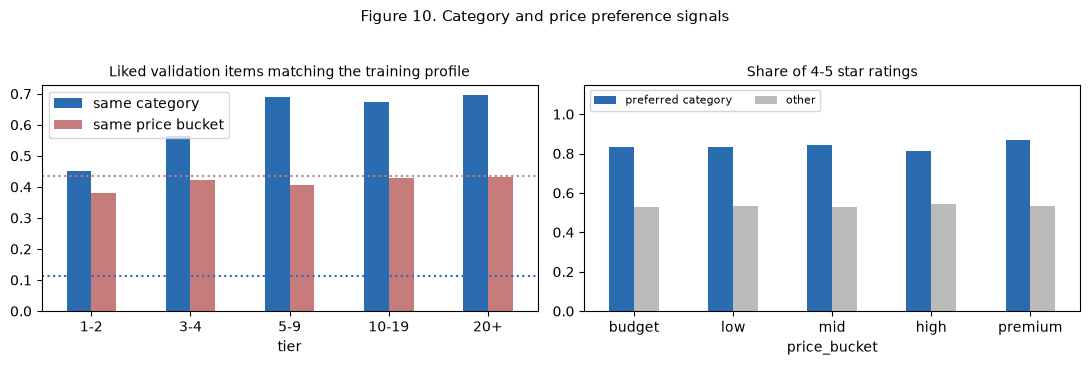

In [14]:
category_by_product = products.set_index("product_id").category
price_by_product = products.set_index("product_id").price_bucket.astype(str)

train_events = state["train_agg"].copy()
train_events["category"] = train_events.product_id.map(category_by_product)
train_events["price_bucket"] = train_events.product_id.map(price_by_product)
liked = val[val.rating >= 4].copy()
liked["category"] = liked.product_id.map(category_by_product)
liked["price_bucket"] = liked.product_id.map(price_by_product)

preferred_category = train_events.groupby("user_id").category.agg(lambda values: values.value_counts().index[0])
preferred_price = train_events.groupby("user_id").price_bucket.agg(lambda values: values.value_counts().index[0])
history_size = train_events.groupby("user_id").size()
liked["tier"] = pd.cut(liked.user_id.map(history_size), tiers_bins, labels=tiers_labels)
liked["same_cat"] = liked.category == liked.user_id.map(preferred_category)
liked["same_pb"] = liked.price_bucket == liked.user_id.map(preferred_price)

# Shuffle customer profiles to estimate a simple chance baseline.
shuffled_users = np.random.default_rng(0).permutation(liked.user_id.values)
chance_category = (liked.category.values == preferred_category.reindex(shuffled_users).values).mean()
chance_price = (liked.price_bucket.values == preferred_price.reindex(shuffled_users).values).mean()
print("same category:     %.3f  (chance %.3f)" % (liked.same_cat.mean(), chance_category))
print("same price bucket: %.3f  (chance %.3f)" % (liked.same_pb.mean(), chance_price))

train_events["preferred_category"] = train_events.category == train_events.user_id.map(preferred_category)
preferred = train_events[train_events.preferred_category]
other = train_events[~train_events.preferred_category]
print("share of 4-5 stars, preferred category: %.2f, other: %.2f" % (
    (preferred.rating >= 4).mean(), (other.rating >= 4).mean()
))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
tier_matches = liked.groupby("tier", observed=True)[["same_cat", "same_pb"]].mean()
tier_matches.columns = ["same category", "same price bucket"]
tier_matches.plot(kind="bar", ax=axes[0], color=["#2b6cb0", "#c77c7c"])
axes[0].axhline(chance_category, ls=":", color="#2b6cb0")
axes[0].axhline(chance_price, ls=":", color="#c77c7c")
axes[0].set_title("Liked validation items matching the training profile", fontsize=10)
axes[0].tick_params(axis="x", rotation=0)

positive_rates = pd.DataFrame({
    "preferred category": preferred.groupby("price_bucket").rating.apply(lambda ratings: (ratings >= 4).mean()),
    "other": other.groupby("price_bucket").rating.apply(lambda ratings: (ratings >= 4).mean()),
})
positive_rates.reindex(["budget", "low", "mid", "high", "premium"]).plot(
    kind="bar", ax=axes[1], color=["#2b6cb0", "#bbbbbb"]
)
axes[1].set_ylim(0, 1.15)
axes[1].legend(fontsize=8, ncol=2, loc="upper left")
axes[1].set_title("Share of 4-5 star ratings", fontsize=10)
axes[1].tick_params(axis="x", rotation=0)
fig.suptitle("Figure 10. Category and price preference signals", y=1.03, fontsize=11)
plt.tight_layout()
savefig("refinement_fig10_eda_preference_signal")
plt.show()

**Finding 1: category preference is visible even for low-history customers.** 66% of liked validation items match the customer's most common training category, compared with 11% for the shuffled baseline, and the 1-2 interaction tier still reaches 45%.

**Finding 2: price is less informative here.** Price-bucket matching is at chance (42% vs. 43%), while ratings depend strongly on category (83% positive in the preferred category vs. 53% elsewhere).

popularity rank correlation, train vs validation: 0.59
top-10% items share - train: 43.5%, liked validation: 52.8%
        share  start  final
item_n                     
0-4     0.024  0.018  0.027
5-9     0.128  0.010  0.008
10-19   0.196  0.013  0.010
20-49   0.234  0.079  0.075
50+     0.419  0.157  0.193


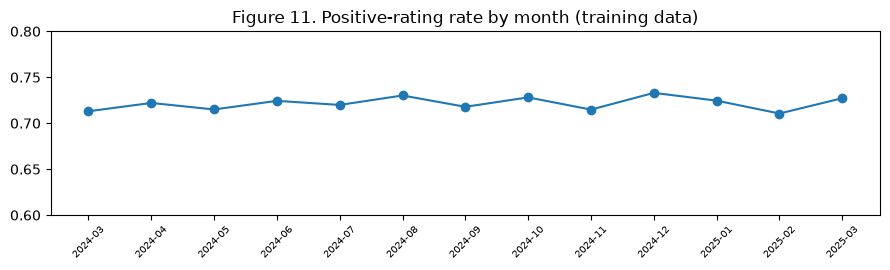

In [15]:
train_counts = state["train_agg"].product_id.value_counts()
validation_counts = val.product_id.value_counts()
counts_by_split = pd.concat([train_counts, validation_counts], axis=1,
                            keys=["train", "validation"]).fillna(0)
rank_correlation = spearmanr(counts_by_split.train, counts_by_split.validation).statistic
print("popularity rank correlation, train vs validation: %.2f" % rank_correlation)

head_set = set(train_counts.index[: int(0.10 * len(train_counts))])
train_head_share = state["train_agg"].product_id.isin(head_set).mean()
validation_head_share = liked.product_id.isin(head_set).mean()
print("top-10%% items share - train: %.1f%%, liked validation: %.1f%%" % (
    100 * train_head_share, 100 * validation_head_share
))

# hit rate by how many training interactions the liked item had
liked["item_n"] = liked.product_id.map(train_counts).fillna(0)
item_bin = pd.cut(liked.item_n, [-1, 4, 9, 19, 49, np.inf],
                  labels=["0-4", "5-9", "10-19", "20-49", "50+"])
start_recommendations = fast_topk(S["Fixed 50/50 hybrid"], state["seen_mask"])
final_recommendations = fast_topk(model_final, state["seen_mask"])
start_hits = []
final_hits = []
for user_id, product_id in zip(liked.user_id, liked.product_id):
    user_index = state["u_idx"][user_id]
    product_index = state["p_idx"][product_id]
    start_hits.append(product_index in start_recommendations[user_index])
    final_hits.append(product_index in final_recommendations[user_index])
liked["hit_start"] = start_hits
liked["hit_final"] = final_hits
hit_rates = liked.groupby(item_bin, observed=True).agg(
    share=("hit_final", "size"),
    start=("hit_start", "mean"),
    final=("hit_final", "mean"),
)
print(hit_rates.assign(share=lambda frame: frame.share / frame.share.sum()).round(3))

training_events = state["train"].copy()
training_events["month"] = pd.to_datetime(training_events.timestamp).dt.to_period("M").astype(str)
monthly_positive_rate = training_events.groupby("month").rating.apply(lambda ratings: (ratings >= 4).mean())
plt.figure(figsize=(9, 2.8))
plt.plot(monthly_positive_rate.index, monthly_positive_rate.values, marker="o")
plt.ylim(0.6, 0.8)
plt.xticks(rotation=45, fontsize=7)
plt.title("Figure 11. Positive-rating rate by month (training data)")
plt.tight_layout()
savefig("refinement_fig11_eda_monthly")
plt.show()

**Finding 3: popular products remain prominent.** 53% of liked validation items come from the training top 10% of products, compared with 44% of training interactions (rank correlation 0.59).

**Finding 4: item cold start is not directly tested.** Only 2.4% of liked validation items had fewer than five training interactions, and the final model hit 2.7% of them versus 19.3% for items with 50 or more.

**Finding 5: no clear monthly pattern appears in training data.** The positive rate stays near 72%.

**Relevance to the project.** On this dataset, the stable blend performs better for low-history users than the adaptive weighting scheme. Future work should add richer product information and evaluate new products with a dedicated cold-start split.

## 5. Critical Assessment of Model Limitations

**Data constraints.** Results come from one synthetic generator whose only preference signal is category, which the refinements rediscovered. Real shoppers may care about price, brand, and season, so dropping price could be wrong on real data. The seed check shows stability across generated datasets, not generalization; real interaction data would be needed to assess that (He & McAuley, 2016).

**Evaluation limits.** A liked rating is not a purchase, and offline evaluation cannot establish real behavior (Jannach & Jugovac, 2019). The pipeline first retains users and products with at least three interactions counted across the full dataset, then splits events chronologically and keeps validation/test events only for users and products present in training. This means the test results apply to a filtered, established-user/item cohort; the full-period count filter may also make evaluation more favorable than a strictly prospective setting.

**Bias.** Over 85% of slots still go to the top 10% of products, and items never shown never gain interactions, reinforcing concentration (Abdollahpouri et al., 2017).

**Scalability.** The dense user × item matrix is manageable at 3,800 × 2,000 but would need terabytes at a million users and 100,000 products. Production needs on-demand scoring from SVD factors, approximate nearest-neighbor search, and scheduled retraining.

**Enhancements.** Richer content features or embeddings, diversity-aware re-ranking (Kaminskas & Bridge, 2016), a new-product split, and post-launch monitoring of coverage and per-tier quality.

### Applicability to other industries

| Context | Benefits | Drawbacks |
| --- | --- | --- |
| General retail | Repeat purchases and clear categories, like this data | Seasonal trends; fit and size matter more than category |
| Streaming and news | Lots of interactions for SVD | Content ages in days; popularity bias shapes what gets popular |
| Online education | Subject category is a strong signal | Ignores prerequisites and course order |
| B2B marketplaces | Small, well-described catalogs suit the content side | Few interactions; one account covers many users |
| Healthcare or finance | Could surface relevant services | High cost of errors, explanations often required, strict privacy review needed; it should not be used without major changes |

## Conclusion

Questioning the earlier choices led to more useful changes than tuning alone. Removing price from the content features and adjusting the blend raised test NDCG@10 from 0.0990 to 0.1193, ahead of SVD, and the ranking change was faster. The model is intended for the Streamlit prototype; real interaction data and a dedicated new-product cold-start test are still needed.

## References

Abdollahpouri, H., Burke, R., & Mobasher, B. (2017). Controlling popularity bias in learning-to-rank recommendation. In *Proceedings of the 11th ACM Conference on Recommender Systems* (pp. 42–46). ACM. https://doi.org/10.1145/3109859.3109912

Burke, R. (2002). Hybrid recommender systems: Survey and experiments. *User Modeling and User-Adapted Interaction, 12*(4), 331–370. https://doi.org/10.1023/A:1021240730564

Cremonesi, P., Koren, Y., & Turrin, R. (2010). Performance of recommender algorithms on top-N recommendation tasks. In *Proceedings of the 4th ACM Conference on Recommender Systems* (pp. 39–46). ACM. https://doi.org/10.1145/1864708.1864721

Ferrari Dacrema, M., Cremonesi, P., & Jannach, D. (2019). Are we really making much progress? A worrying analysis of recent neural recommendation approaches. In *Proceedings of the 13th ACM Conference on Recommender Systems* (pp. 101–109). ACM. https://doi.org/10.1145/3298689.3347058

He, R., & McAuley, J. (2016). Ups and downs: Modeling the visual evolution of fashion trends with one-class collaborative filtering. In *Proceedings of the 25th International Conference on World Wide Web* (pp. 507–517). https://doi.org/10.1145/2872427.2883037

Jannach, D., & Jugovac, M. (2019). Measuring the business value of recommender systems. *ACM Transactions on Management Information Systems, 10*(4), Article 16. https://doi.org/10.1145/3370082

Kaminskas, M., & Bridge, D. (2016). Diversity, serendipity, novelty, and coverage: A survey and empirical analysis of beyond-accuracy objectives in recommender systems. *ACM Transactions on Interactive Intelligent Systems, 7*(1), Article 2. https://doi.org/10.1145/2926720

Koren, Y., Bell, R., & Volinsky, C. (2009). Matrix factorization techniques for recommender systems. *Computer, 42*(8), 30–37. https://doi.org/10.1109/MC.2009.263

Krichene, W., & Rendle, S. (2020). On sampled metrics for item recommendation. In *Proceedings of the 26th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining* (pp. 1748–1757). ACM. https://doi.org/10.1145/3394486.3403226